In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


def visualize_qps(csv_path: Path,
                  power_df_dvfs: pd.DataFrame, 
                  power_df_ours: pd.DataFrame, 
                  time_bucket_ms: int = 10000, 
                  save_name: str = None, 
                  start_time: int = 0,
                  end_time: int = 5 * 60, ):
    """
    Generate a plot showing QPS for the first 35 minutes from an LLM inference request trace.
    """
    # Read the CSV
    df = pd.read_csv(csv_path)

    # Convert arrived_at to microseconds relative to first request
    df = df[(df['arrived_at'] >= start_time) & (df['arrived_at'] <= end_time)]
    df['timestamp_us'] = (df['arrived_at'] - start_time) * 1e6

    # Compute time bucket for each row
    df['time_bucket'] = (df['timestamp_us'] // (time_bucket_ms * 1000)).astype(int)

    # Aggregate QPS
    agg = df.groupby('time_bucket').agg(
        qps=('timestamp_us', 'count'),
        tps=('num_prefill_tokens', 'sum')
    ).reset_index()


    # Fill in missing time buckets with zeroes
    all_buckets = pd.DataFrame({
        'time_bucket': np.arange(df['time_bucket'].min(), df['time_bucket'].max() + 1)
    })
    agg = pd.merge(all_buckets, agg, on='time_bucket', how='left').fillna(0)

    agg['qps'] = agg['qps'] / (time_bucket_ms / 1000.0)
    agg['tps'] = agg['tps'] / (time_bucket_ms / 1000.0)
    # Filter data for the first 35 minutes
    max_time_bucket = end_time 
    agg = agg[agg['time_bucket'] <= max_time_bucket]



    # Create a figure with two subplots in a single column
    fig, axes = plt.subplots(4, 1, figsize=(10,10), constrained_layout=True)

    power_df_ours['power'] = (
        power_df_ours['power']
        .rolling(window=50, center=True)
        .mean()
    )
    power_df_dvfs['power'] = (
        power_df_dvfs['power']
        .rolling(window=50, center=True)
        .mean()
    )
    sns.set_theme(context="paper", style="whitegrid")
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['power'], label='Power Ours (W)', ax=axes[0])
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['power'], label='Power DVFS (W)', ax=axes[0])
    axes[0].set_xlabel('Time (minutes)', fontsize=18)
    axes[0].set_ylabel('Power (W)', fontsize=18)
    axes[0].tick_params(axis='both', which='major', labelsize=14)
    axes[0].set_ylim(0, 6500)
    axes[0].set_xlim(0, 5)
    axes[0].legend(fontsize=14)

    ax = sns.lineplot(x=agg['time_bucket'] * (time_bucket_ms / 1000.0) / 60, y=agg['tps'], ax=axes[2])
    axes[2].set_xlabel('Time (minutes)', fontsize=18)
    axes[2].set_ylabel('TPS', fontsize=18)
    axes[2].set_ylim(0, 35000)
    axes[2].set_xlim(0, 5)
    axes[2].tick_params(axis='both', which='major', labelsize=14)

    ax = sns.lineplot(x=agg['time_bucket'] * (time_bucket_ms / 1000.0) / 60, y=agg['qps'], ax=axes[3])
    axes[3].set_xlabel('Time (minutes)', fontsize=18)
    axes[3].set_ylabel('RPS', fontsize=18)
    axes[3].set_ylim(0, 170)
    axes[3].set_xlim(0, 5)
    axes[3].tick_params(axis='both', which='major', labelsize=14)
    # Show the plots
    plt.show()

    # # Save the figure if save_name is provided
    # if save_name:
    #     fig.savefig(save_name, format="svg")


def get_combined_power_df(power_csv_paths: list[Path]) -> pd.DataFrame:
    """
    Combine power data from multiple CSV files by summing power values at each timestamp.
    """
    combined_df = None

    for path in power_csv_paths:
        df = pd.read_csv(path / "power_log.csv")
        stats_df = pd.read_csv(path / "engine_0.csv")
        df = df[(df['Timestamp'] > stats_df['now'].min()) & (df['Timestamp'] < stats_df['now'].max())]
        df['power'] = df[[col for col in df.columns if col.startswith("GPU_") and col.endswith("_power_w")]].sum(axis=1)
        if combined_df is None:
            combined_df = df[['Timestamp', 'power']].copy()
        else:
            combined_df = pd.merge_asof(combined_df.sort_values('Timestamp'), 
                                        df[['Timestamp', 'power']].sort_values('Timestamp'), 
                                        on='Timestamp', 
                                        direction='nearest')
            combined_df['power'] = combined_df['power_x'] + combined_df['power_y']
            combined_df = combined_df.drop(columns=['power_x', 'power_y'])
    combined_df["Timestamp"] = combined_df["Timestamp"] - combined_df["Timestamp"].min()
    return combined_df

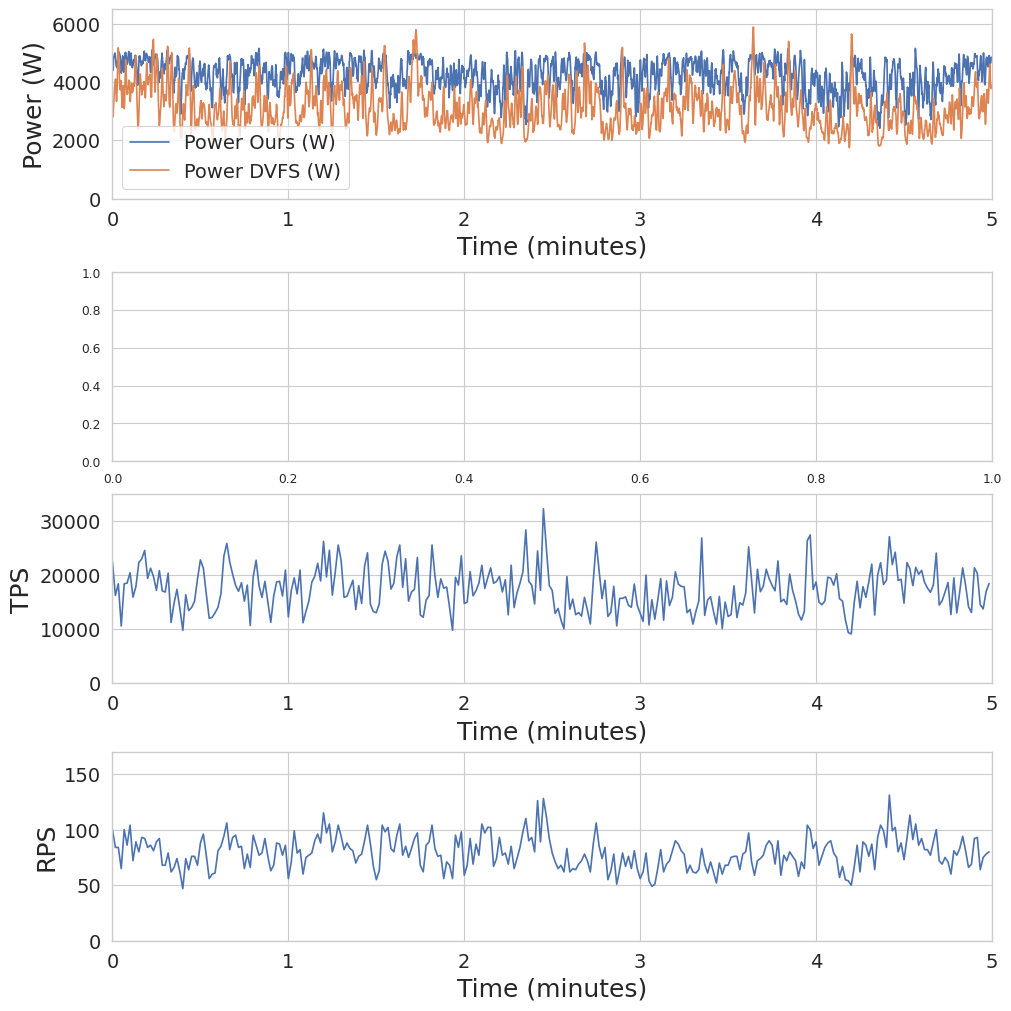

In [103]:
power_df_dvfs = get_combined_power_df([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1_DVFS/prefill_0_Jan04210608_gpu1'),
                                  Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1_DVFS/prefill_0_Jan04210620'),
                                  Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1_DVFS/prefill_2_Jan04210608_gpu1'),
                                  Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1_DVFS/prefill_2_Jan04210620')])
power_df_ours = get_combined_power_df([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1/prefill_0_Jan04214813_gpu1'),
                                  Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1/prefill_0_Jan04214823'),
                                  Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1/prefill_2_Jan04214813_gpu1'),
                                  Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1/prefill_2_Jan04214824')])
visualize_qps(csv_path=Path('azure_2024_code_sharegpt-ctx-len_qps93.46_req-cnt200000.csv'), 
              power_df_dvfs=power_df_dvfs,
              power_df_ours=power_df_ours,
              time_bucket_ms=1000, 
              save_name="figs/plot_8.1b_rps_67p.svg",
              start_time=0,
              end_time=5 * 60)